# Importation des librairies

In [3]:
import numpy as np
import pandas as pd
import sklearn 

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Première partie

In [6]:
X , y = sklearn.datasets.make_circles(n_samples= 400, noise= 0.1, factor= 0.3)

In [32]:
#  Ajout des points abberants

x_dirty = np.array([[24.9, 0.1],
                    [23, 1],
                    [24.8, 0.6],
                    [27, 0.1]])

# Ajout aux données
X_dirty= np.append(X, x_dirty, axis=0)
y_dirty = np.append(y , [1, 1, 1, 1], axis=0)

In [33]:
## Create a dataframe

df = pd.DataFrame(dict(x=X_dirty[:,0] , y=X_dirty[:,1], label= 1 - y_dirty))
print(df.columns[0])
colors = {0 : 'red', 1:'blue'}
df_grouped = df.groupby('label')

x


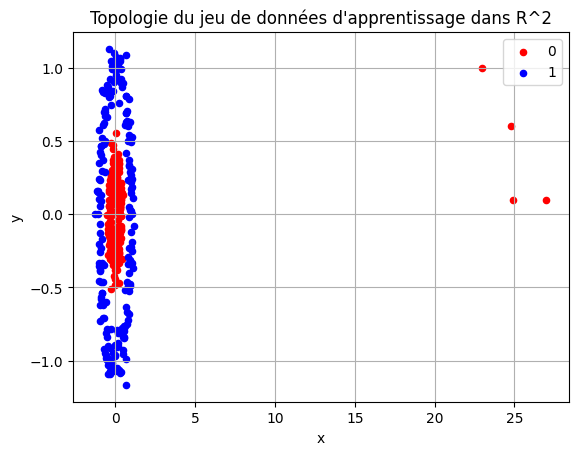

In [34]:
# Graphique 
fig , ax = plt.subplots()
for key, group in df_grouped:
    group.plot(ax=ax , kind = 'scatter', x='x', y='y', label=key, color=colors[key])

plt.grid()
plt.title("Topologie du jeu de données d'apprentissage dans R^2")
plt.show()


Ce qu'on remarque c'est la forte densité de probabilité sur la droite d'équation : y = 0  , que la densité de probabilité est très forte pour les éléments de la classe 0.

(à appronfondir)

## Modèles génératifs QDA et effondrement paramétrique

In [41]:
## Entrainement des données
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# On crée nos datasets de train et de test. => On prend 80% train 20% test
X_train, X_test, y_train, y_test = train_test_split(X_dirty, y_dirty, test_size=0.2, random_state=42)

# Analyse quadratique discriminante
qda_clf = QuadraticDiscriminantAnalysis()

qda_clf.fit(X_train, y_train)


,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


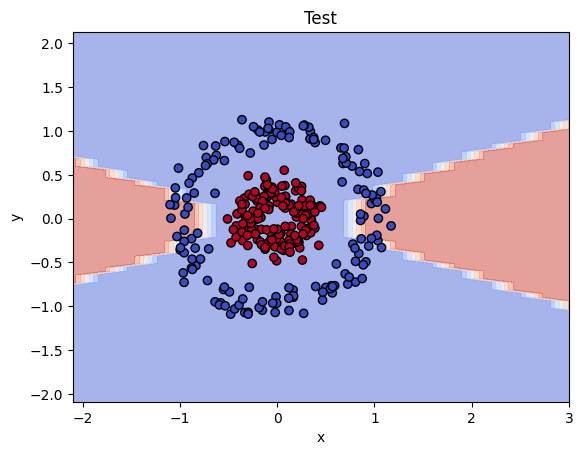

In [42]:
from numpy.ma import right_shift
# Plotting the tree boundaries
disp = DecisionBoundaryDisplay.from_estimator(qda_clf, 
                                              X_train, 
                                              response_method="predict",
                                              xlabel=df.columns[0], ylabel=df.columns[1],
                                              alpha=0.5, 
                                              cmap=plt.cm.coolwarm)
# Plotting the data points    
disp.ax_.scatter(X_train[:, 0], X_train[:, 1], 
                 c=y_train, edgecolor="k",
                 cmap=plt.cm.coolwarm)

plt.title("Test")
plt.xlim(right=3)
plt.show()

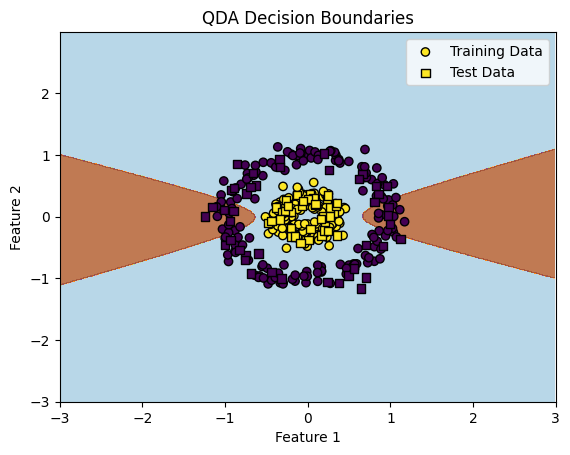

In [43]:
# Create a mesh to plot the decision boundaries
x_min, x_max = (-3 , 3)
y_min, y_max = (-3, 3)
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict class using the classifier for each point in the mesh
Z = qda_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundaries
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', marker='o', label='Training Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', marker='s', label='Test Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.xlim(right=3)
plt.title('QDA Decision Boundaries')
plt.legend()
plt.show()

Le fait qu'il y ait des outliers pour la classe 0 biaise totalement notre séparateur qui nous renvoit des frontières sorties du chapeau ...

La formule de la distance de Mahalanobis :

In [45]:
![Distance_mahalanobis]("images/distance_mahalanobis.jpg")

zsh:1: unknown file attribute: i
